#5th July

> goal: full EDA

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

print(train.shape, test.shape)
train.head()

palette = ['#F76587', '#D96B47', '#A6771D', '#697C1D', '#1C793D', '#006F61']

(45000, 15) (5000, 15)


In [ ]:
train.isnull().sum()

,0
Student_ID,0
Age,0
Gender,0
Degree,0
Branch,0
CGPA,0
Internships,0
Projects,0
Coding_Skills,0
Communication_Skills,0


no missing values, dataset is clean

In [ ]:
train['Placement_Status'].value_counts()
train['Placement_Status'].value_counts(normalize=True) * 100

,proportion
Placement_Status,
Not Placed,63.751111
Placed,36.248889


roughly a 1.76 : 1 ratio of not placed: placed

it's imbalanced but not severely


Now we are visualising the dataset to see what type of distribution each factor shows.

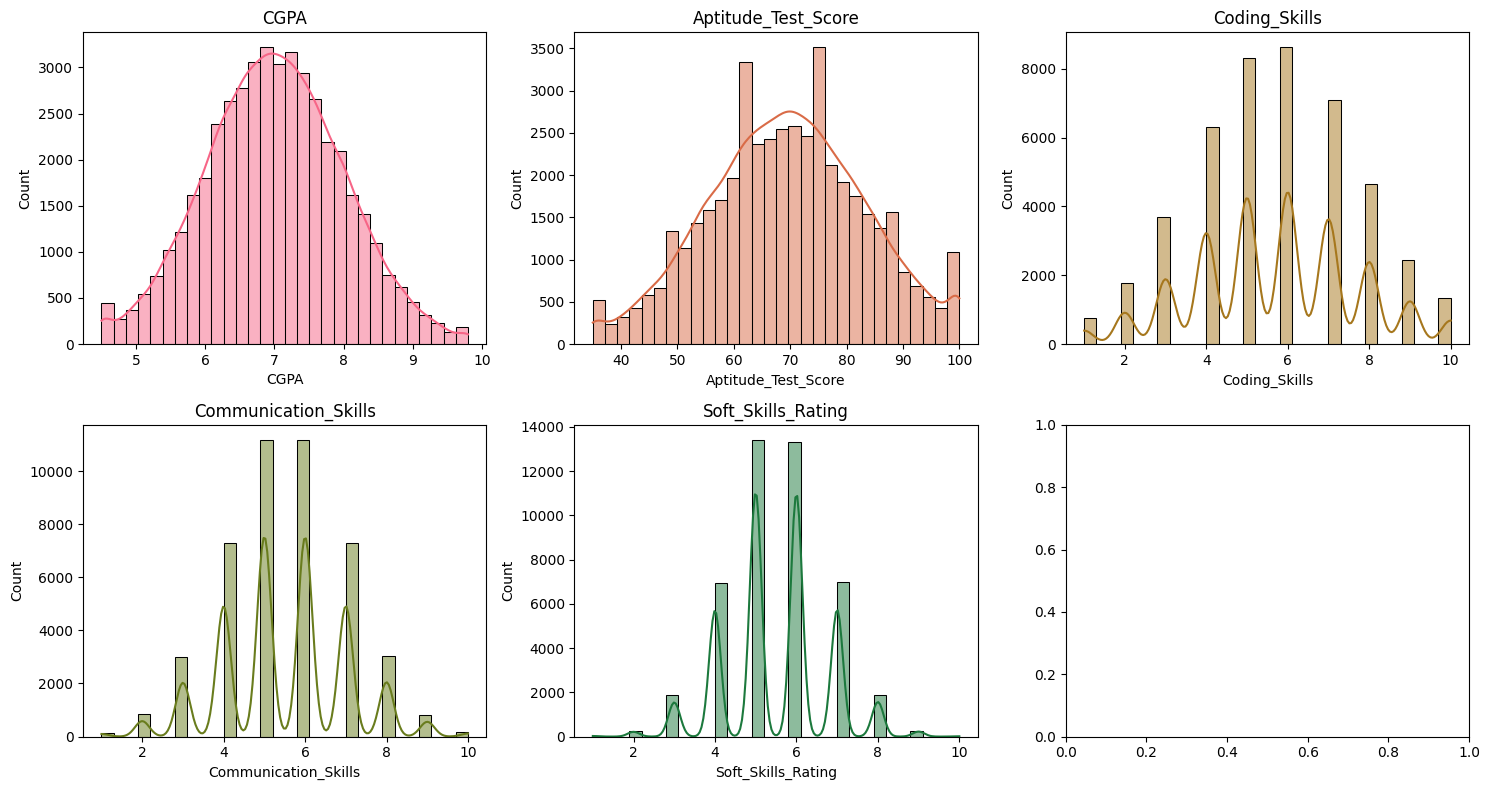

In [ ]:
numeric_cols = ['CGPA', 'Aptitude_Test_Score', 'Coding_Skills', 'Communication_Skills', 'Soft_Skills_Rating']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    sns.histplot(train[col], bins=30, ax=axes[i], kde=True, color=palette[i])
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

CGPA and Aptitude_Test_Score show graphs which appear to be normal (bell shaped)

coding_skills, communication_Skills, Soft_Skills_Rating appear to be multimodal at first glance; but it is because the range was assumed to be continuous but upon check these attributes are measured on a scale of 1-10 and are discrete values, hence they appear to show a multimodal curve

to fix that; first we confirm that the entries are discrete, and what their ranges are:


In [ ]:
for col in ['Coding_Skills', 'Communication_Skills', 'Soft_Skills_Rating']:
    print(col, ':', sorted(train[col].unique()))

Coding_Skills : [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)]
Communication_Skills : [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)]
Soft_Skills_Rating : [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)]


the output confirms that all three coloumns take integer values (which means observations are discrete) and they all range from 1-10; these are "discrete ratings"

now to replot them, countplot seems the right way instead of histograms, so we replotted them using countplot

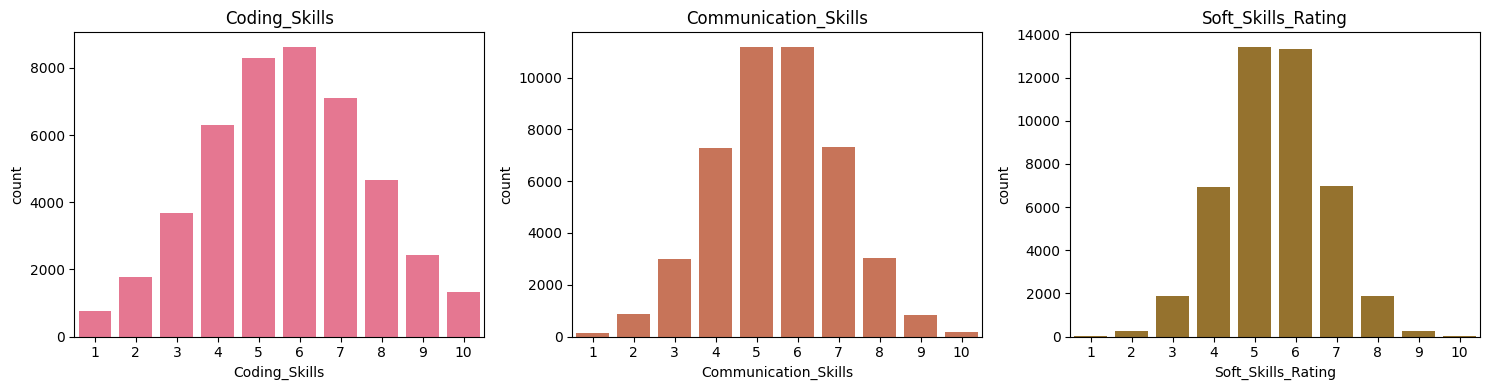

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
discrete_cols = ['Coding_Skills', 'Communication_Skills', 'Soft_Skills_Rating']
for i, col in enumerate(discrete_cols):
    sns.countplot(data=train, x=col, ax=axes[i], color=palette[i])
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

these are also bell-shaped and evenly distributed; normal distribution

Now, we are running bivariate analysis to see whats the correlation between obvious factors like CGPA, internship, backlogs and branch have with getting placed.

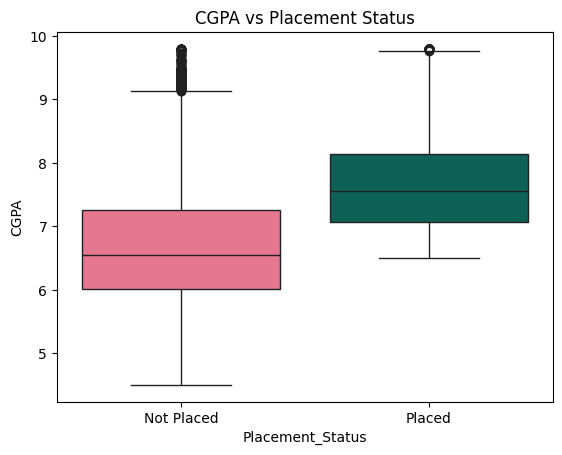

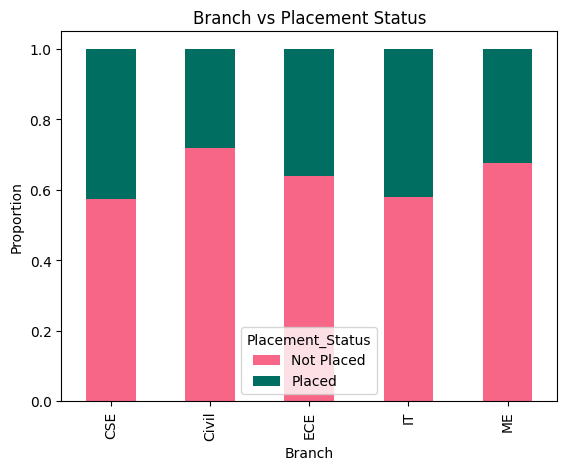

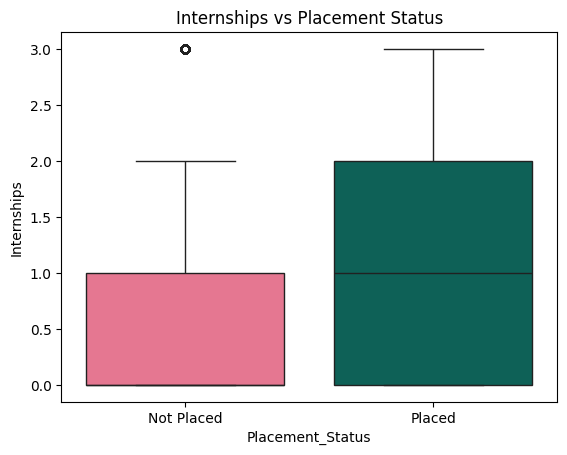

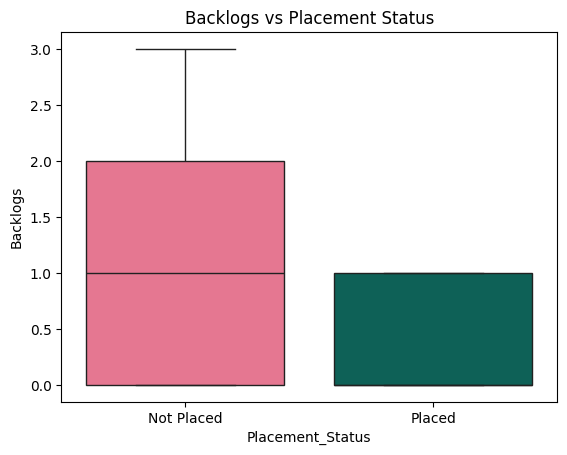

In [ ]:
placement_palette = {'Not Placed': '#F76587', 'Placed': '#006F61'}

# CGPA vs Placement_Status
sns.boxplot(data=train, x='Placement_Status', y='CGPA', hue='Placement_Status', palette=placement_palette, legend=False)
plt.title('CGPA vs Placement Status')
plt.show()

# Branch vs Placement_Status
pd.crosstab(train['Branch'], train['Placement_Status'], normalize='index').plot(
    kind='bar', stacked=True, color=[placement_palette['Not Placed'], placement_palette['Placed']]
)
plt.title('Branch vs Placement Status')
plt.ylabel('Proportion')
plt.show()

# Internships vs Placement_Status
sns.boxplot(data=train, x='Placement_Status', y='Internships', hue='Placement_Status', palette=placement_palette, legend=False)
plt.title('Internships vs Placement Status')
plt.show()

# Backlogs vs Placement_Status
sns.boxplot(data=train, x='Placement_Status', y='Backlogs', hue='Placement_Status', palette=placement_palette, legend=False)
plt.title('Backlogs vs Placement Status')
plt.show()

Looking at the graphs, some obvious points become clear:

*  Placed students have a CGPA median of 7.5 whereas not placed median is 6.5, also overall lower and uperbounds are also more for placed students v/s not placed students; even tho there's a slight overlap, it can be said that placed students show higher CGPA than not placed students in general
*  for internships: not placed median is at 0 while placed median is at 1; there's a lot of overlap but it can still be used as a moderate signal
*  for backlogs: not placed median lies at 1 with IQR 0-2, while placed median is close to 0; a reasonable direction, though there's a lot of overlap which also means a lot of placed students also have 1 backlog.
*  for branches: they do follow the belief people have about CSE having highest placements and civil having the lowest, but the difference is not as drastic; CSE and IT have highest placed rates ~40-42%, ECE and ME in between ~32-36%, and Civil at the lowest ~28%.

apart from these obvious observations, there is also a finding which is unusual and important -

*  the outliers of the not placed student CGPA: the outliers are ranging all the way from ~9.2 to ~9.8 suggesting some very high CGPA holders also dont get placed and that the effect these student's performance in other areas are likely what can explain that.


>  also as these are boxplots and only show quartiles, these are good only to grasp on the data in broader light and see some easy to identify patterns; it can not be used to make precise assumptions

Now to wrap up our EDA, we are gonna observe correlation between different factors using a **Heatmap**

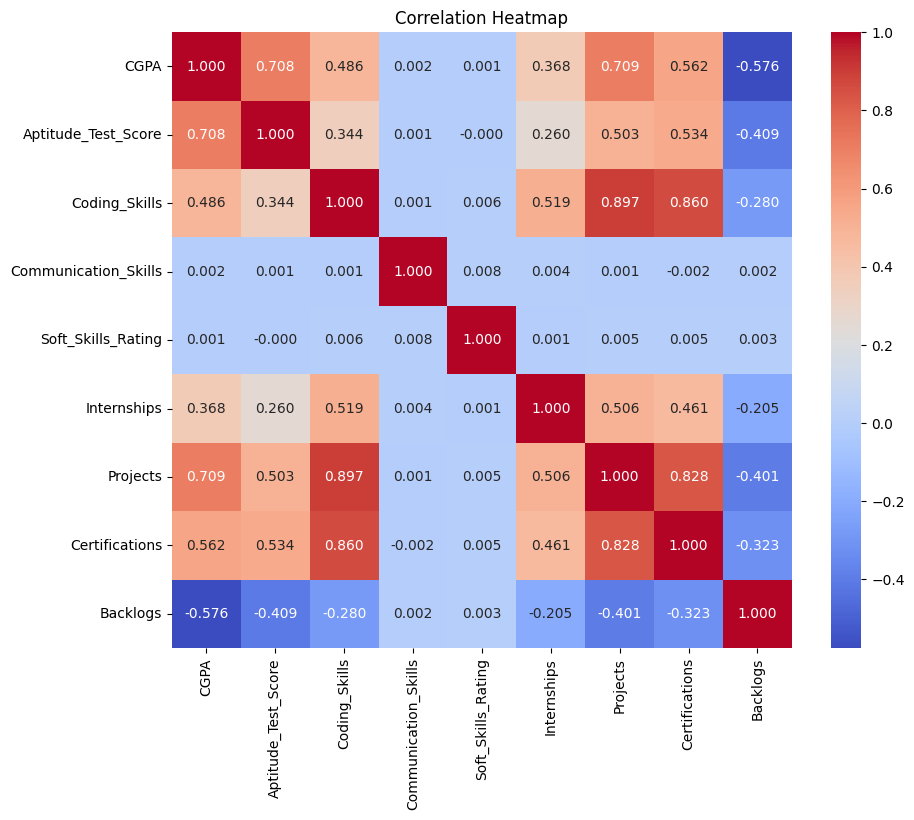

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(train[numeric_cols + ['Internships', 'Projects', 'Certifications', 'Backlogs']].corr(),
            annot=True, cmap='coolwarm', fmt='.3f')
plt.title('Correlation Heatmap')
plt.show()

From the heatmap, these are some notable clusters (high correlattion):
*  Coding skills<->Projects at 0.897
*  Coding skills<->Certifications at 0.860
*  Projects<->Certifications at 0.828
*  CGPA<->Projects at 0.709
and so on...
The more correlated two factors are the more it is likely that they are carrying the same information; hence if you know one you can predict the other quite well; this can be coined as multicollinearity.
these highly correlated factors may seem helpful but they can create problems when we run models to point out which factors have contributed to the outcome, cause instead of telling what the greater idea is, the model will confuse the contribution of two factors which seems to be identical and "split" the credit.
hence it becomes important to observe correlations so as to figure out which ones pose the most trouble for the model

> note: coding skills, projects and certification seem to be highly correlated (upto almost 0.9)